In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("ecommerce.csv", low_memory=False)

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Convert date columns
df["Order Date"] = pd.to_datetime(df["Order Date"], errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")

# Convert numeric columns
numeric_cols = ["Sales", "Quantity", "Discount", "Profit", "Shipping Cost", "Aging"]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check missing values
print(df.isnull().sum())

C:\Users\PURNANDA PARIDA\AppData\Local\Temp\ipykernel_14564\1631088405.py:12: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Ship Date"] = pd.to_datetime(df["Ship Date"], errors="coerce")


Order ID                0
Order Date          31100
Ship Date               0
Aging                   1
Ship Mode               0
Product Category        0
Product                 0
Sales                   1
Quantity                2
Discount                1
Profit                  0
Shipping Cost           1
Order Priority          2
Customer ID             1
Customer Name           0
Segment                 1
City                    0
State                   0
Country                 0
Region                  1
Months                  0
dtype: int64


In [8]:
# 1)Overall Sales Performance.
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_quantity = df["Quantity"].sum()
total_shipping_cost = df["Shipping Cost"].sum()

print("Total Sales :", total_sales)
print("Total Profit :", total_profit)
print("Total Quantity Sold :", total_quantity)
print("Total Shipping Cost :", total_shipping_cost)

Total Sales : 8023170.0
Total Profit : 3730073.3000000003
Total Quantity Sold : 153729.0
Total Shipping Cost : 373021.4


Product
T - Shirts       692912.0
Titak watch      637260.0
Running Shoes    626080.0
Jeans            609092.0
Formal Shoes     595335.0
Shirts           547624.0
Fossil Watch     444564.0
Casula Shoes     340990.0
Suits            304655.0
Sports Wear      240295.0
Name: Sales, dtype: float64


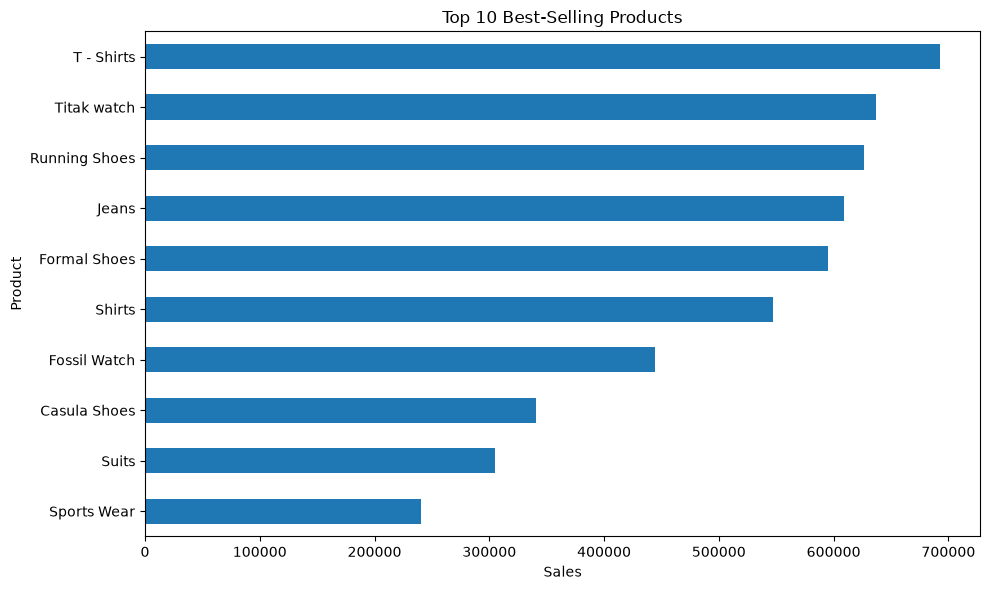

In [10]:
# 2)Top 10 Best-Selling Products

top_products = (
    df.groupby("Product")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(top_products)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
top_products.sort_values().plot(kind="barh")
plt.title("Top 10 Best-Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

                        Sales     Profit  Quantity
Product Category                                  
Auto & Accessories  1096928.0   484313.2   22392.0
Electronic           394738.0   174190.6    8211.0
Fashion             5212097.0  2483955.2   92071.0
Home & Furniture    1319407.0   587614.3   31055.0


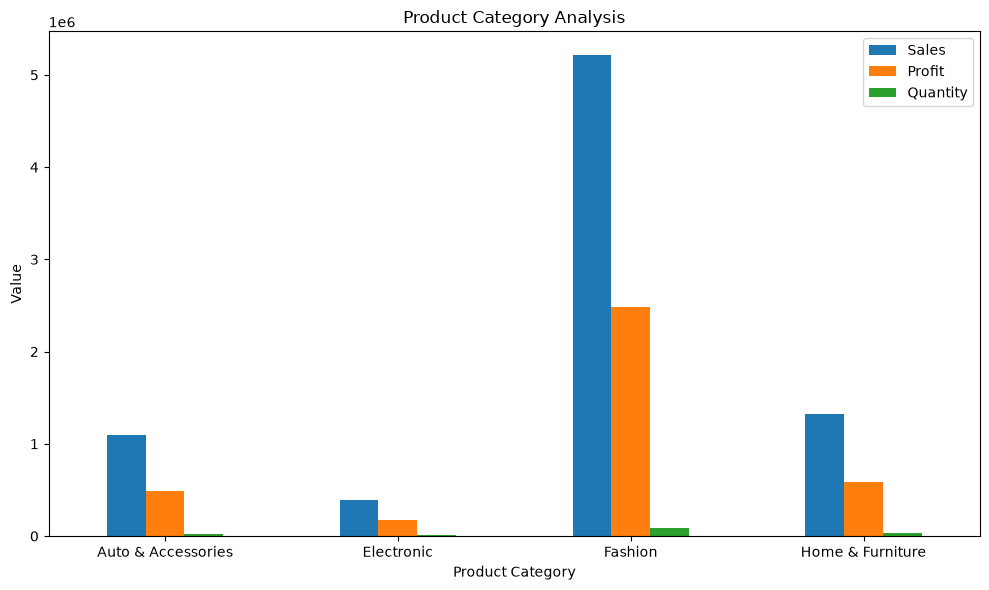

In [11]:
# 3)Product Category Analysis.
category_analysis = df.groupby("Product Category").agg({
    "Sales": "sum",
    "Profit": "sum",
    "Quantity": "sum"
})

print(category_analysis)

category_analysis.plot(kind="bar", figsize=(10,6))
plt.title("Product Category Analysis")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Months
Feb    610240.0
Nov    656663.0
Sep    658844.0
Apr    659404.0
Jun    664560.0
Aug    670788.0
May    672547.0
Jan    676313.0
Jul    685152.0
Mar    686681.0
Oct    688905.0
Dec    693073.0
Name: Sales, dtype: float64


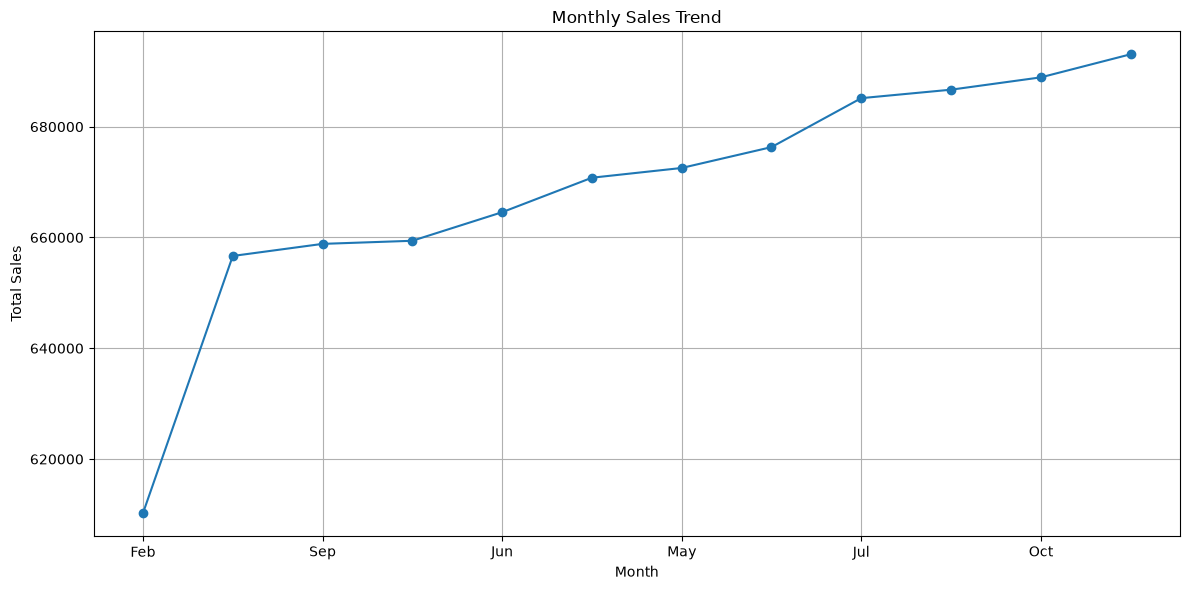

In [12]:
# 4. Monthly Sales Trend.
import matplotlib.pyplot as plt

monthly_sales = (
    df.groupby("Months")["Sales"]
      .sum()
      .sort_values()
)

print(monthly_sales)

plt.figure(figsize=(12,6))
monthly_sales.plot(marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

                    Sales    Profit
Region                             
4orth               117.0      33.5
Africa           713074.0  332220.0
Canada            60003.0   27783.1
Caribbean        260495.0  120608.1
Central         1735900.0  804210.0
Central Asia     321005.0  149529.7
EMEA             788072.0  368570.7
East             446468.0  206694.5
North            750365.0  349269.5
North Asia       369816.0  170918.3
Oceania          544827.0  253691.7
So3th               211.0      99.4
South           1034533.0  479016.5
Southeast Asia   500712.0  235598.1
West             497432.0  231775.8


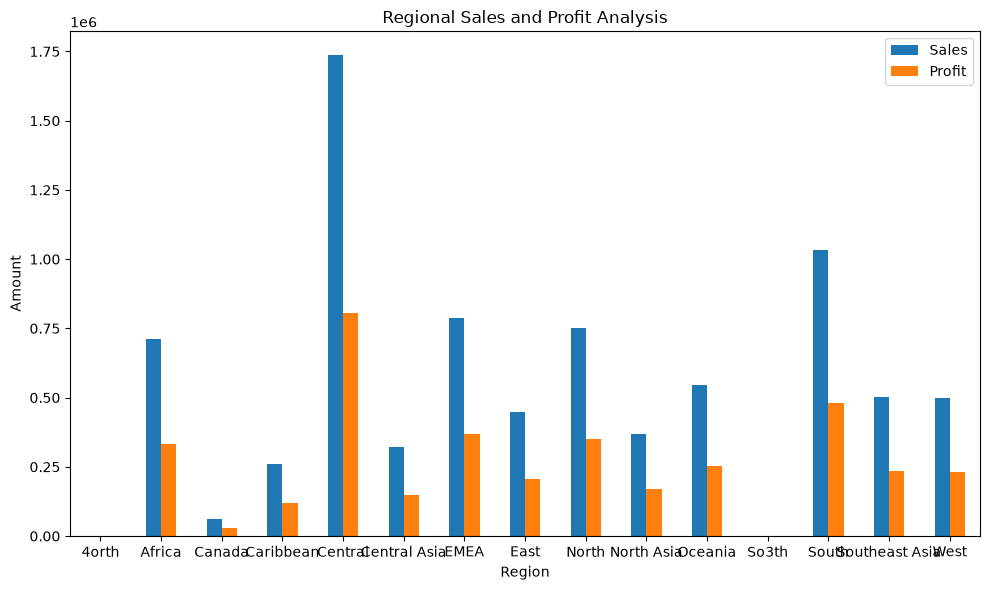

In [13]:
# 5. Regional Sales Analysis.
regional_analysis = df.groupby("Region").agg({
    "Sales":"sum",
    "Profit":"sum"
})

print(regional_analysis)

regional_analysis.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Regional Sales and Profit Analysis")
plt.xlabel("Region")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Country
United States     1562170.0
Australia          442452.0
France             437441.0
Mexico             418795.0
Germany            323619.0
China              296640.0
United Kingdom     253975.0
Brazil             247794.0
India              244746.0
Indonesia          222379.0
Name: Sales, dtype: float64


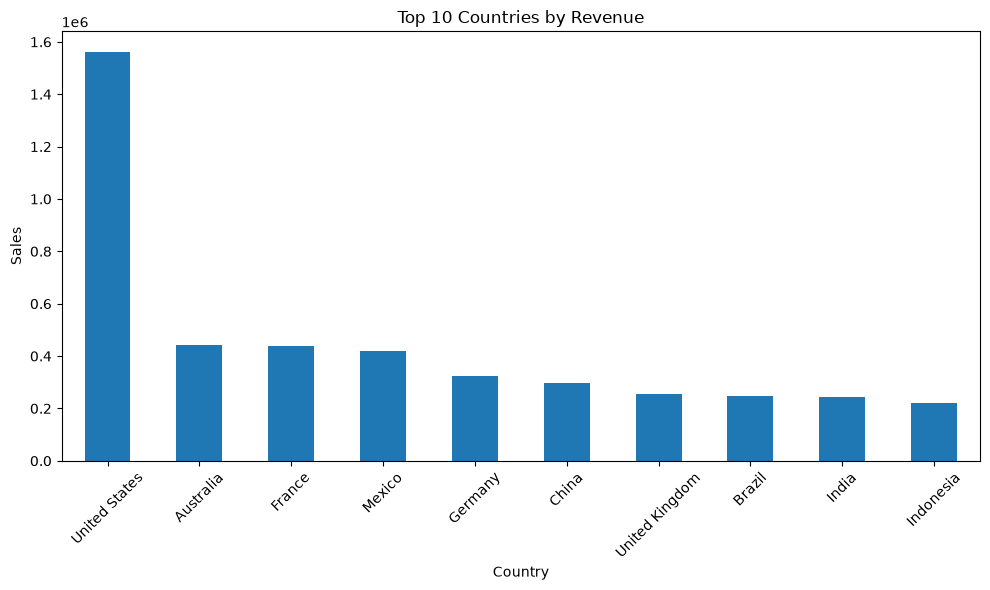

In [14]:
# Question 6: Country-wise Revenue Analysis.
country_sales = (
    df.groupby("Country")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(country_sales)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Top 15 States
State
California                142905.2
England                   109275.5
New York                   80855.4
Texas                      72492.1
Ile-de-France              70627.9
New South Wales            56253.6
Queensland                 52913.3
North Rhine-Westphalia     50167.2
San Salvador               45997.0
National Capital           43966.6
Pennsylvania               43675.1
Washington                 36666.3
Distrito Federal           34988.7
Illinois                   34632.3
Victoria                   34400.5
Name: Profit, dtype: float64

Bottom 15 States
State
Isparta               0.8
Kabarole              6.8
Inhambane             7.2
Caras-Severin        12.4
Savanes              15.6
Bitola               17.0
Guelmim-Es Semara    17.5
Ibb                  18.0
Shumen               19.5
Kara                 19.5
Okayama              20.3
South Chungcheong    20.3
Grand Gedeh          21.2
Novosibirsk          21.3
Mashonaland West     21.3
Name: Profit

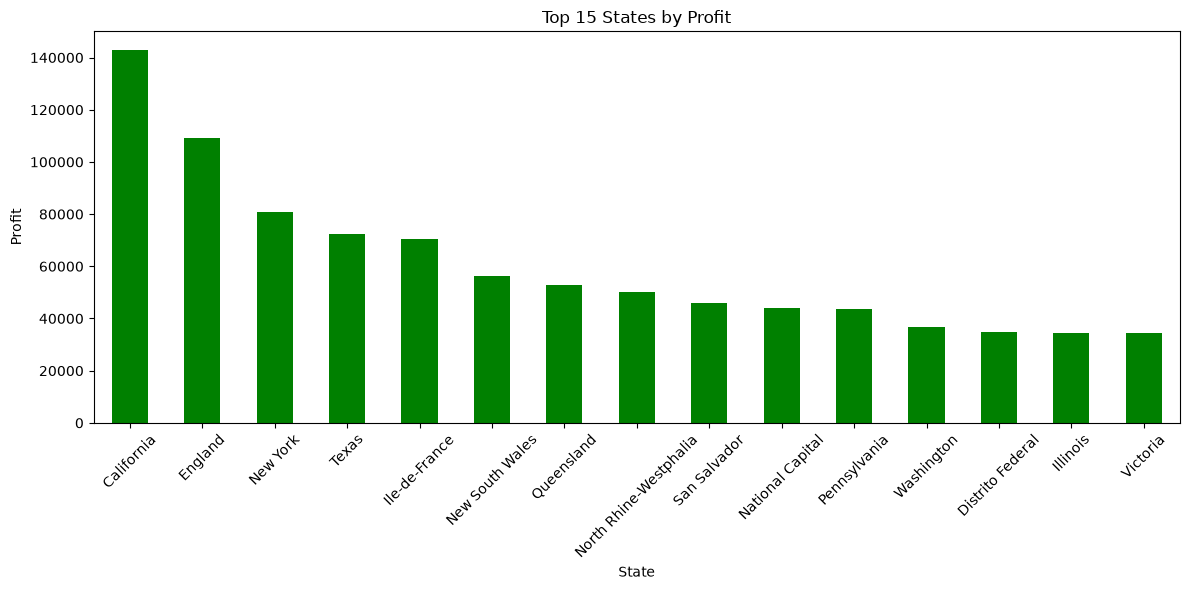

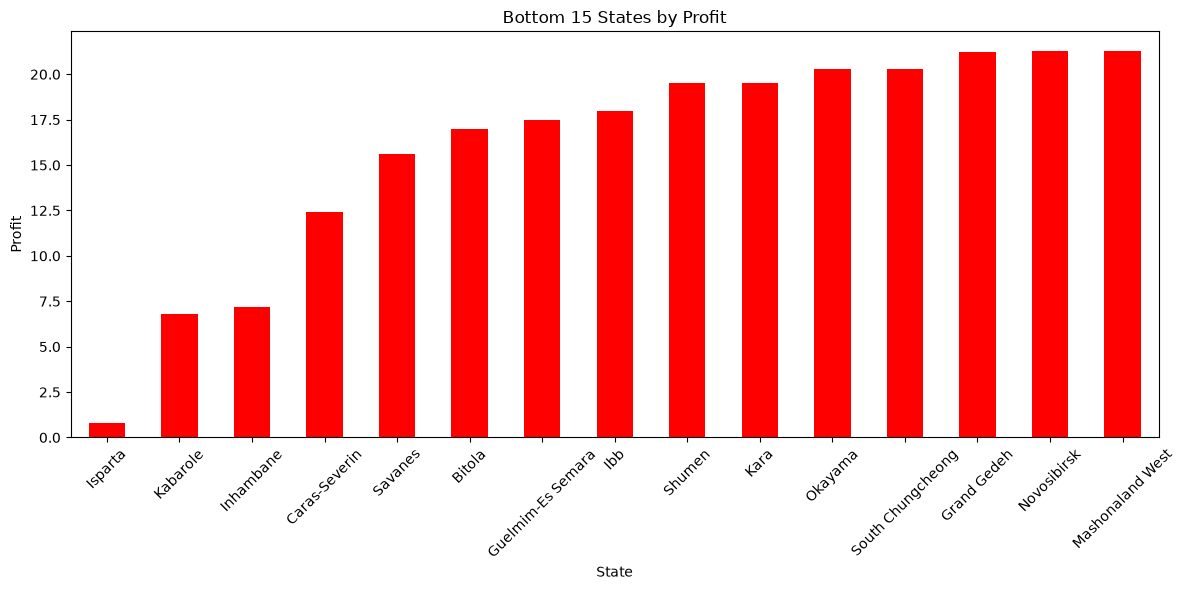

In [15]:
# Question 7: State-wise Profit Analysis.
state_profit = df.groupby("State")["Profit"].sum()

top15 = state_profit.sort_values(ascending=False).head(15)
bottom15 = state_profit.sort_values().head(15)

print("Top 15 States")
print(top15)

print("\nBottom 15 States")
print(bottom15)

plt.figure(figsize=(12,6))
top15.plot(kind="bar", color="green")
plt.title("Top 15 States by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
bottom15.plot(kind="bar", color="red")
plt.title("Bottom 15 States by Profit")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

             Total_Sales  Total_Profit  Average_Order_Value
Segment                                                    
Consumer       4135010.0     1915800.9           155.938077
Corporate      2421560.0     1128812.0           156.948603
Home Office    1466528.0      685446.0           156.982231


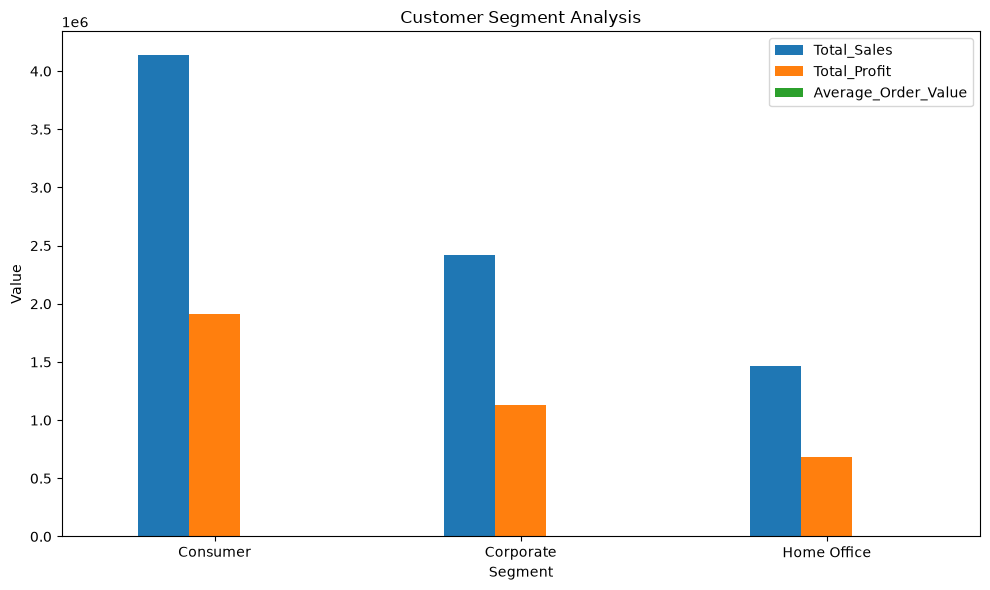

In [16]:
# Question 8: Customer Segment Analysis.
segment_analysis = df.groupby("Segment").agg(
    Total_Sales=("Sales","sum"),
    Total_Profit=("Profit","sum"),
    Average_Order_Value=("Sales","mean")
)

print(segment_analysis)

segment_analysis.plot(kind="bar", figsize=(10,6))
plt.title("Customer Segment Analysis")
plt.ylabel("Value")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                Average_Shipping_Cost  Average_Aging  Total_Sales
Ship Mode                                                        
45788                        0.600000       9.000000        114.0
First Class                  6.454165       5.541850    1096814.0
Same Day                     6.455313       1.000000     394738.0
Second Class                 5.703114       5.454845    1319407.0
Standard Class               8.070382       5.491503    5212097.0


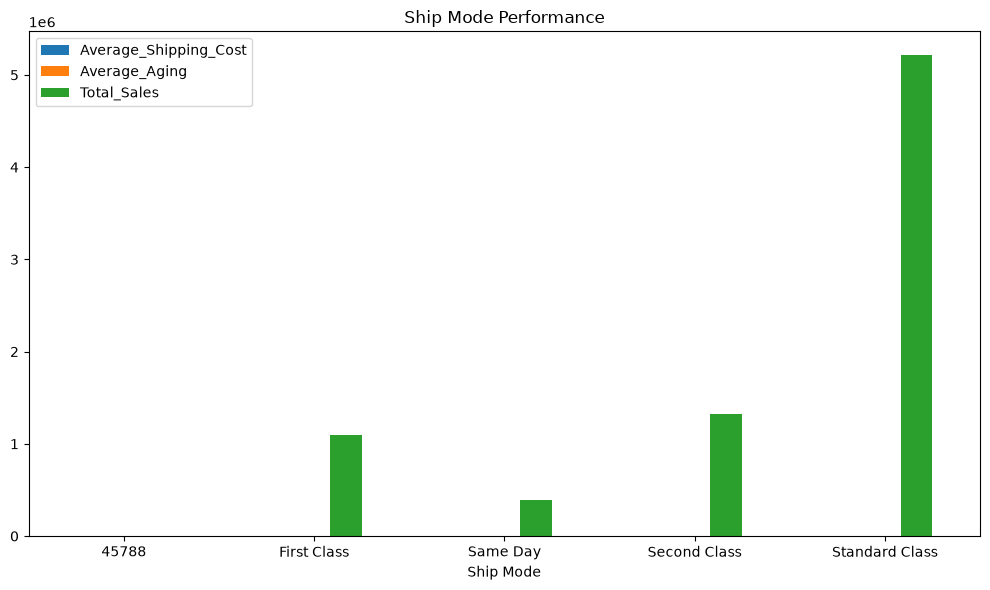

In [17]:
# Question 9: Ship Mode Performance.
ship_mode = df.groupby("Ship Mode").agg(
    Average_Shipping_Cost=("Shipping Cost","mean"),
    Average_Aging=("Aging","mean"),
    Total_Sales=("Sales","sum")
)

print(ship_mode)

ship_mode.plot(kind="bar", figsize=(10,6))
plt.title("Ship Mode Performance")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation between Discount and Profit: -0.11907838667523728


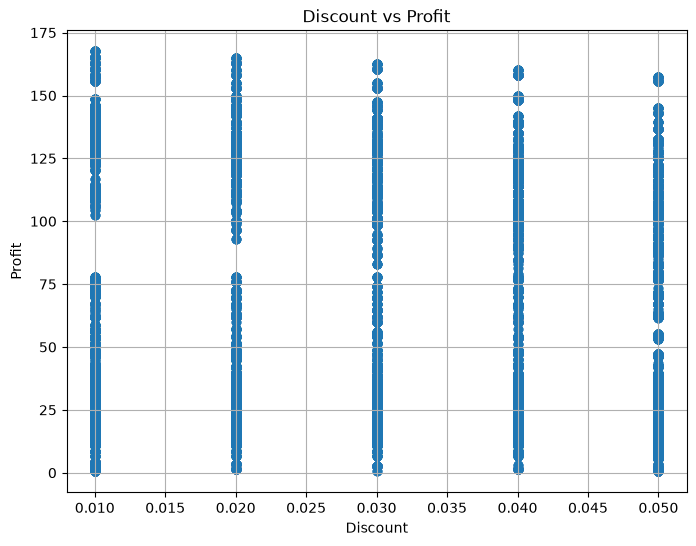

In [18]:
# Question 10: Discount vs Profit Analysis.
import matplotlib.pyplot as plt

correlation = df["Discount"].corr(df["Profit"])

print("Correlation between Discount and Profit:", correlation)

plt.figure(figsize=(8,6))
plt.scatter(df["Discount"], df["Profit"], alpha=0.5)
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.grid(True)
plt.show()

                Total_Sales  Total_Profit
Order Priority                           
Critical           544404.0      239239.6
High              2348534.0     1081889.7
Low                411004.0      195904.5
Medium            4718747.0     2212750.8


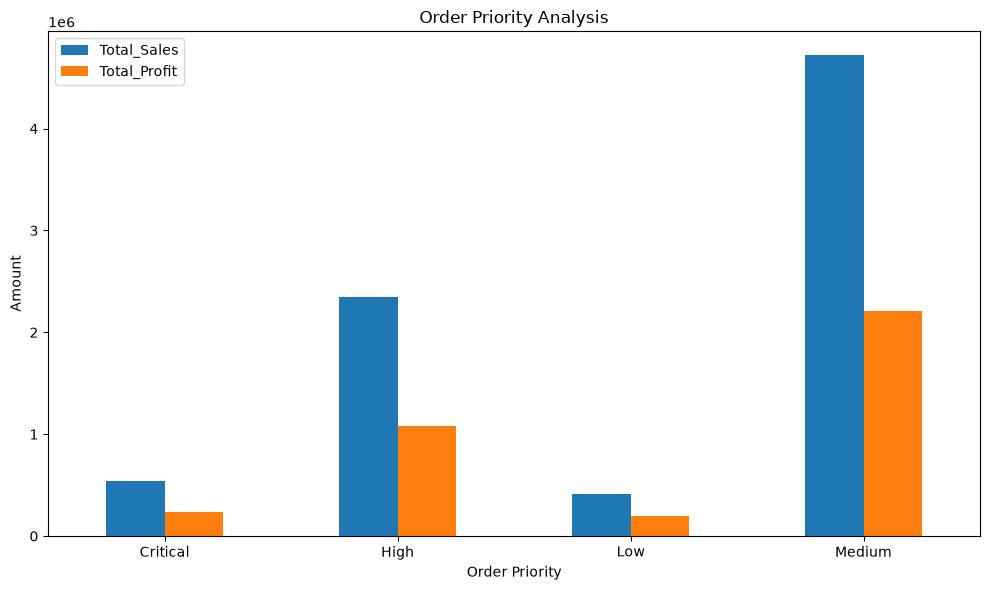

In [19]:
# Question 11: Order Priority Analysis.
order_priority = df.groupby("Order Priority").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

print(order_priority)

import matplotlib.pyplot as plt

order_priority.plot(kind="bar", figsize=(10,6))
plt.title("Order Priority Analysis")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

                   Total_Sales  Total_Profit
Customer Name                               
Mcclain O'Donnell      17015.0        7592.2
Weber Halladay         16632.0        7877.1
Leon Sissman           16321.0        7960.3
Booth Pistole          16291.0        7707.6
Ellis Carmichael       16174.0        7891.9
Bates Gockenbach       15968.0        7545.8
Bell Bickford          15932.0        7748.0
Spears Thornton        15922.0        7443.6
Graves Garza           15833.0        7830.7
Flores Brooks          15807.0        7250.5
Robertson Coakley      15635.0        7529.7
Kelly Braden           15593.0        7418.9
Skinner Nguyen         15332.0        7269.1
Ryan Dominguez         15160.0        7132.2
Mcdowell Roelle        15048.0        6838.7
Preston Savely         15010.0        7165.0
Barnett Garverick      14946.0        7321.4
Wiley Pölking          14883.0        7234.3
Oneill Williams        14719.0        6853.8
Meyers Pelletier       14637.0        6772.8


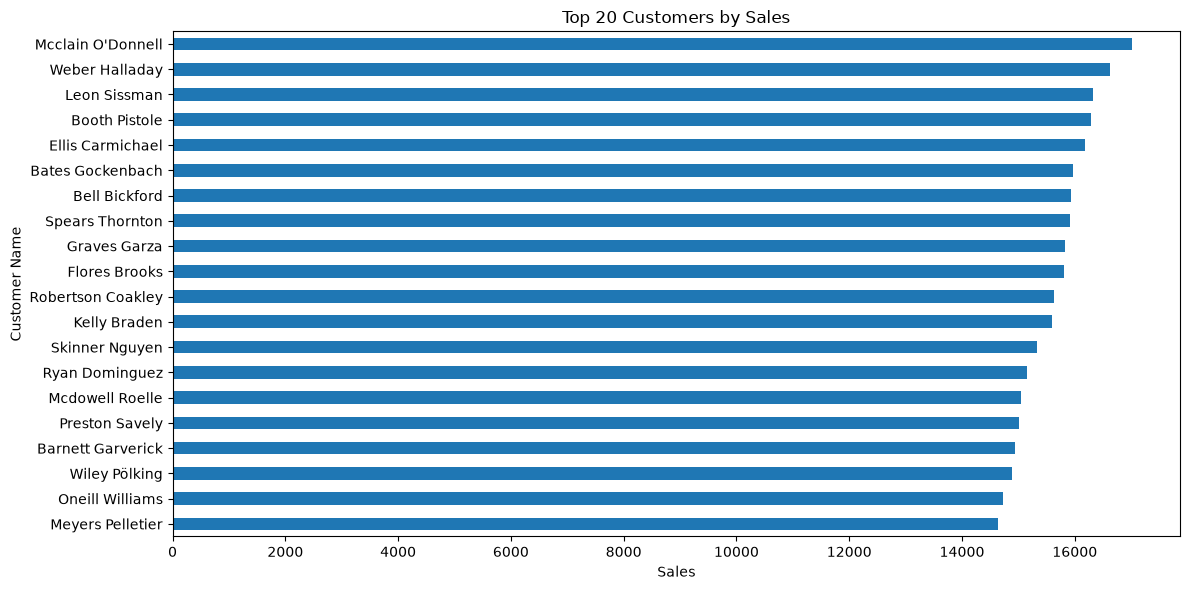

In [20]:
# Question 12: Top Customers Analysis.
top_customers = df.groupby("Customer Name").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

top20 = top_customers.sort_values(by="Total_Sales", ascending=False).head(20)

print(top20)

plt.figure(figsize=(12,6))
top20["Total_Sales"].sort_values().plot(kind="barh")
plt.title("Top 20 Customers by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

In [21]:
# Question 13: Loss-Making Orders.
loss_orders = df[df["Profit"] < 0]

print(loss_orders[[
    "Order ID",
    "Product",
    "Product Category",
    "Discount",
    "Shipping Cost",
    "Profit"
]])

print("\nAverage Discount:", loss_orders["Discount"].mean())
print("Average Shipping Cost:", loss_orders["Shipping Cost"].mean())

category_loss = loss_orders.groupby("Product Category")["Profit"].sum()
print("\nLoss by Category")
print(category_loss)

Empty DataFrame
Columns: [Order ID, Product, Product Category, Discount, Shipping Cost, Profit]
Index: []

Average Discount: nan
Average Shipping Cost: nan

Loss by Category
Series([], Name: Profit, dtype: float64)


                Average_Aging
Ship Mode                    
45788                9.000000
First Class          5.541850
Same Day             1.000000
Second Class         5.454845
Standard Class       5.491503

Fastest Shipping Mode: Same Day


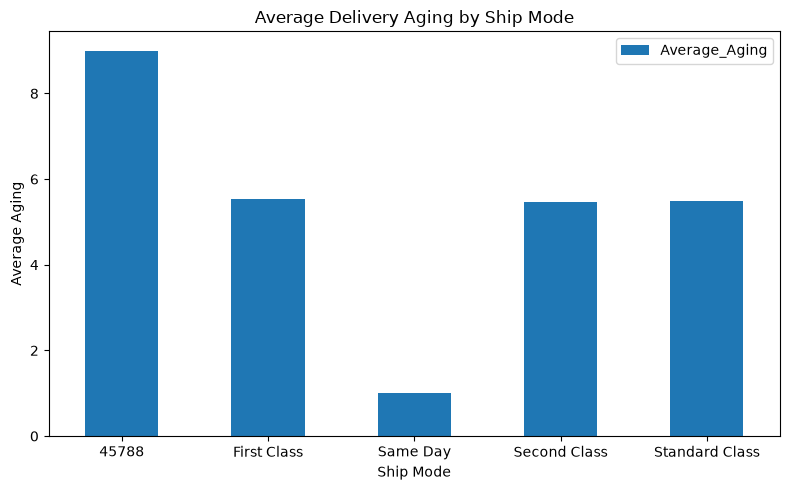

In [22]:
# Question 14: Aging Analysis.
aging_analysis = df.groupby("Ship Mode").agg(
    Average_Aging=("Aging", "mean")
)

print(aging_analysis)

fastest = aging_analysis["Average_Aging"].idxmin()
print("\nFastest Shipping Mode:", fastest)

aging_analysis.plot(kind="bar", figsize=(8,5))
plt.title("Average Delivery Aging by Ship Mode")
plt.ylabel("Average Aging")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

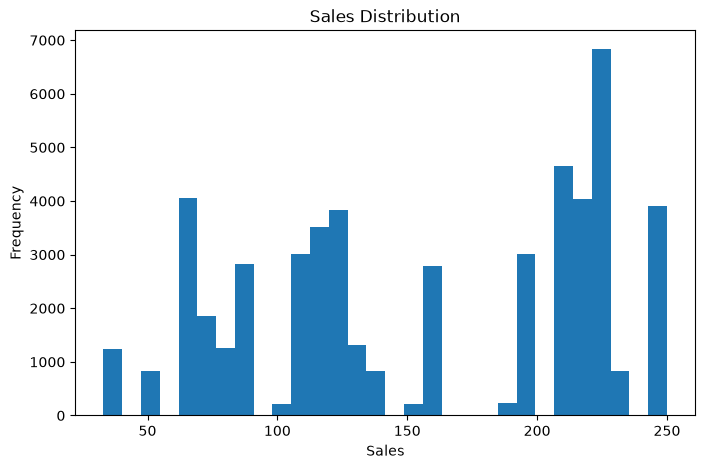

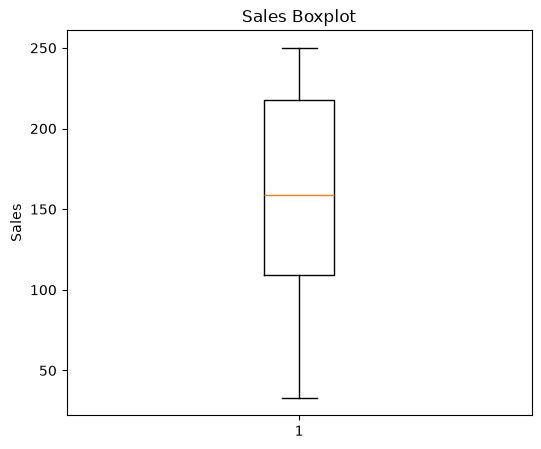

In [24]:
# Question 15: Sales Distribution.
import matplotlib.pyplot as plt

sales = df["Sales"].dropna()

# Histogram
plt.figure(figsize=(8,5))
plt.hist(sales, bins=30)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Boxplot
plt.figure(figsize=(6,5))
plt.boxplot(sales)
plt.title("Sales Boxplot")
plt.ylabel("Sales")
plt.show()

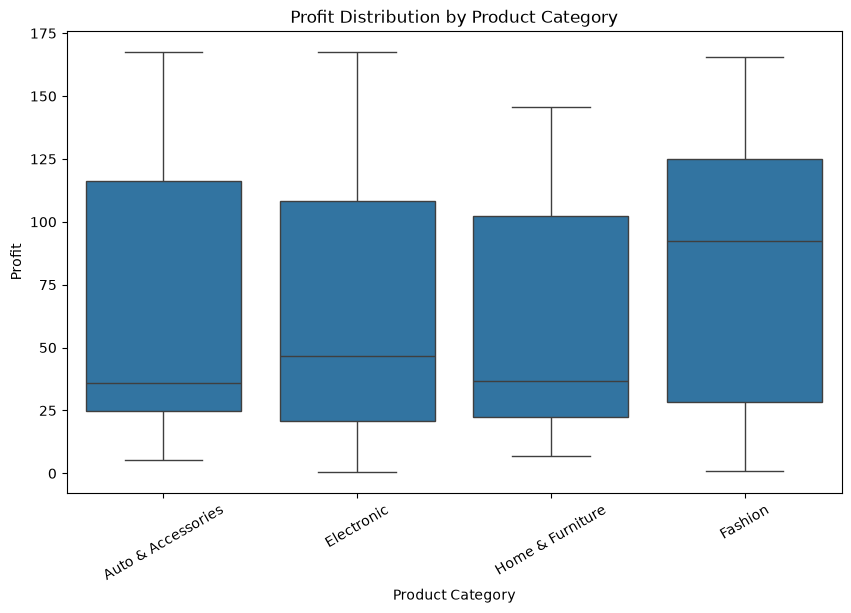

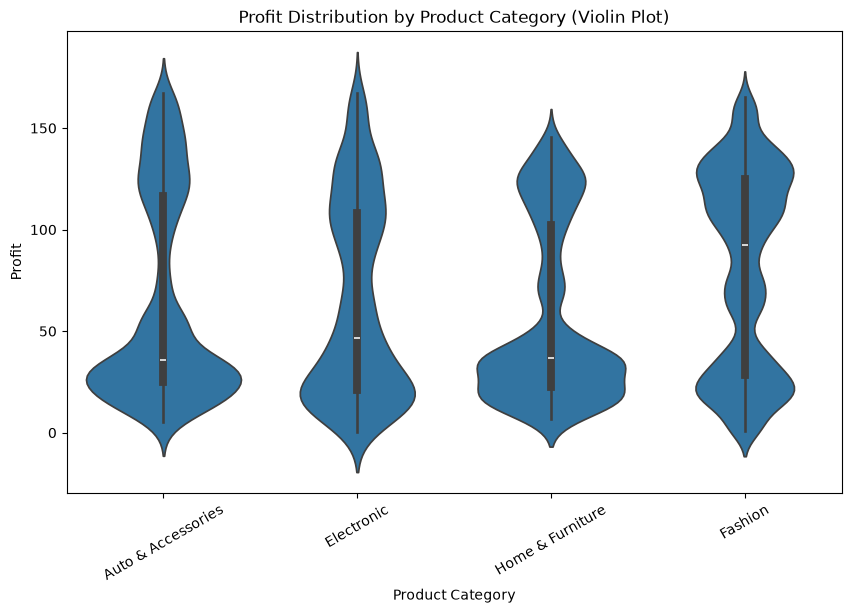

In [30]:
# Question 16: Profit Distribution by Product Category.
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="Product Category", y="Profit")
plt.title("Profit Distribution by Product Category")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10,6))
sns.violinplot(data=df, x="Product Category", y="Profit")
plt.title("Profit Distribution by Product Category (Violin Plot)")
plt.xticks(rotation=30)
plt.show()

                  Sales  Quantity  Discount    Profit  Shipping Cost     Aging
Sales          1.000000 -0.000573 -0.007228  0.921516       0.921262  0.014835
Quantity      -0.000573  1.000000  0.007131 -0.176278      -0.176640 -0.002449
Discount      -0.007228  0.007131  1.000000 -0.119078      -0.119391  0.000132
Profit         0.921516 -0.176278 -0.119078  1.000000       0.999982  0.015231
Shipping Cost  0.921262 -0.176640 -0.119391  0.999982       1.000000  0.015170
Aging          0.014835 -0.002449  0.000132  0.015231       0.015170  1.000000


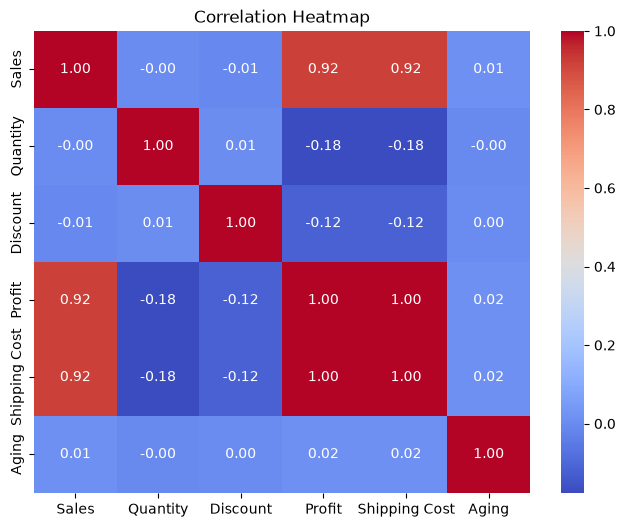

In [26]:
# Question 17: Correlation Analysis (Heatmap).
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[["Sales","Quantity","Discount","Profit","Shipping Cost","Aging"]].corr()

print(corr)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
# Question 18: High-Value Orders.
average_sales = df["Sales"].mean()

high_value = df[df["Sales"] > average_sales]

print("Average Sales:", average_sales)
print("Number of High Value Orders:", len(high_value))

print(high_value[[
    "Order ID",
    "Customer Name",
    "Product",
    "Sales",
    "Profit",
    "Region"
]])

Average Sales: 156.43061865117278
Number of High Value Orders: 26301
            Order ID      Customer Name                 Product  Sales  \
1          AU-2015-2      Alvarado Kriz            Car Speakers  211.0   
4          AU-2015-5       Rowe Jackson                    Tyre  250.0   
8          AU-2015-9         Wall Olsen  Car Pillow & Neck Rest  231.0   
10        AU-2015-11         Johns Reed            Car Speakers  211.0   
13        AU-2015-14    Johnson Abelman                    Tyre  250.0   
...              ...                ...                     ...    ...   
51249  FA-2015-30735       Nunez Lanier                   Jeans  218.0   
51253  FA-2015-30739        Powers Gute           Running Shoes  224.0   
51254  FA-2015-30740     Francis Jarboe            Formal Shoes  213.0   
51256  FA-2015-30742     Bentley Zypern             Titak watch  228.0   
51257  FA-2015-30743  Mclaughlin Leslie            Fossil Watch  159.0   

       Profit      Region  
1       112.0 

In [28]:
# Question 19: Customer Purchase Frequency.
customer_analysis = df.groupby("Customer Name").agg(
    Total_Orders=("Order ID","count"),
    Total_Sales=("Sales","sum"),
    Average_Order_Value=("Sales","mean")
)

repeat_customers = customer_analysis[customer_analysis["Total_Orders"] > 1]

print("Top Customers by Number of Orders")
print(customer_analysis.sort_values("Total_Orders", ascending=False).head(20))

print("\nRepeat Customers")
print(repeat_customers)

Top Customers by Number of Orders
                   Total_Orders  Total_Sales  Average_Order_Value
Customer Name                                                    
Mcclain O'Donnell           108      17015.0           157.546296
Spears Thornton             106      15922.0           150.207547
Bates Gockenbach            102      15968.0           156.549020
Flores Brooks               102      15807.0           154.970588
Booth Pistole               102      16291.0           159.715686
Weber Halladay              101      16632.0           164.673267
May Französisch             100      14430.0           144.300000
Bell Bickford                98      15932.0           162.571429
Ellis Carmichael             97      16174.0           166.742268
Robertson Coakley            96      15635.0           162.864583
Kelly Braden                 96      15593.0           162.427083
Maldonado Jenkins            95      14327.0           150.810526
Bond Overcash                95      14621

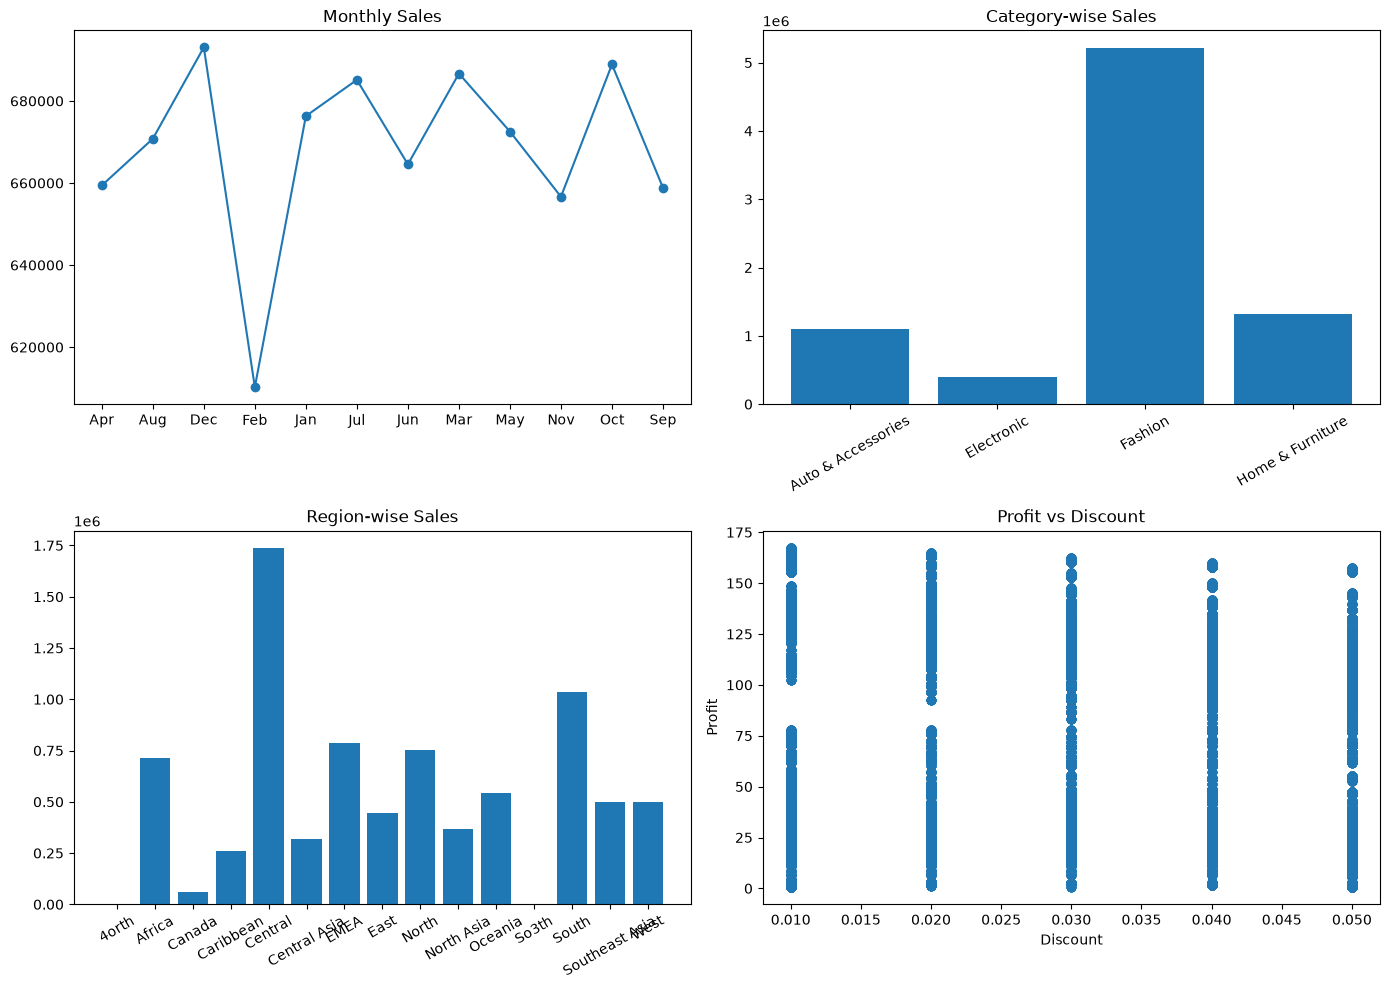

========== EXECUTIVE DASHBOARD ==========
Total Sales: 8023170.0
Total Profit: 3730073.3000000003
Total Orders: 51290
Total Customers: 51289


In [29]:
# Question 20: Executive Sales Dashboard.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2,2, figsize=(14,10))

# Monthly Sales
monthly_sales = df.groupby("Months")["Sales"].sum()
ax[0,0].plot(monthly_sales.index, monthly_sales.values, marker="o")
ax[0,0].set_title("Monthly Sales")

# Category-wise Sales
category_sales = df.groupby("Product Category")["Sales"].sum()
ax[0,1].bar(category_sales.index, category_sales.values)
ax[0,1].set_title("Category-wise Sales")
ax[0,1].tick_params(axis='x', rotation=30)

# Region-wise Sales
region_sales = df.groupby("Region")["Sales"].sum()
ax[1,0].bar(region_sales.index, region_sales.values)
ax[1,0].set_title("Region-wise Sales")
ax[1,0].tick_params(axis='x', rotation=30)

# Profit vs Discount
ax[1,1].scatter(df["Discount"], df["Profit"])
ax[1,1].set_title("Profit vs Discount")
ax[1,1].set_xlabel("Discount")
ax[1,1].set_ylabel("Profit")

plt.tight_layout()
plt.show()

print("========== EXECUTIVE DASHBOARD ==========")
print("Total Sales:", df["Sales"].sum())
print("Total Profit:", df["Profit"].sum())
print("Total Orders:", df["Order ID"].nunique())
print("Total Customers:", df["Customer ID"].nunique())